# Libraries and functions

In [7]:
from astropy.time import Time
import pandas as pd
import warnings
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import random
from ipywidgets import interact

warnings.filterwarnings('ignore')

In [8]:
# Julian dates stored in text files must have this bias added to them when they
# are converted to conventional julian dates (eg, with AstroPy).
JULDATE_BIAS = 2440000.0

def read_obs_pred_file(pred_file, no_date_parse=False, no_juldate_bias=False):
    """Return parsed obs or pred file.

    Args
       pred_file: Path to pred file
       no_date_parse: (optional) set to true to disable parsing dates,
         which is much faster.
    Returns
       Pandas data frame with the juldate column replaced with datetime
       instances.
    """
    if no_juldate_bias:
        juldate_offset = 0
    else:
        juldate_offset = JULDATE_BIAS

    df = pd.read_csv(pred_file, sep='\\s+', comment='#')

    if not no_date_parse:
        df['juldate'] = [
            Time(float(s) + juldate_offset, format='jd').to_datetime()
            for s in df['juldate']
        ]
    
    return df


def read_locs_file(locs_file):
    locs_df = pd.read_csv(
        locs_file, sep=r'\s+',
        names=['sat_time_jd', 'sat_lon', 'carrot_num', 'sat_lat', 'radii']
    )

    locs_df['juldate'] = [
        Time(float(jd), format='jd').to_datetime()
        for jd in locs_df['sat_time_jd']
    ]

    return locs_df

In [9]:
def rmse_year_data(ace_data, stereo_data):
    # Calculates the RMSE of ace and stereo data
    
    ace_rms_error = {}
    
    # ACE RMSE
    for year in range(2010, 2025):
        start_date = datetime(year, 1, 1)
        end_date = datetime(year, 12, 31)
    
        mask = (ace_data.juldate > start_date) & (ace_data.juldate <= end_date)
        ace_rms_error[year] = np.sqrt(np.mean(np.square(ace_data.Vp_obs[mask]-ace_data.Vp_pred[mask])))
    
    # STEREO RMSE
    stereo_rms_error = {}
    for year in range(2010, 2025):
        start_date = datetime(year, 1, 1)
        end_date = datetime(year, 12, 31)
    
        mask = (stereo_data.juldate > start_date) & (stereo_data.juldate <= end_date)
        stereo_rms_error[year] = np.sqrt(np.mean(np.square(stereo_data.Vp_obs[mask]-stereo_data.Vp_pred[mask])))

    return ace_rms_error, stereo_rms_error

In [10]:
def moving_average(data, window):
    data = np.asarray(data, dtype=float)
    smoothed = np.full(len(data), np.nan)
    half = window // 2
    for i in range(half, len(data) - half):
        smoothed[i] = np.mean(data[i - half : i + half + 1])
    return smoothed

# Load in Data

## Location Data

In [11]:
acel2_locs = read_locs_file(r'./locations/Acel2_locs.dat')

In [12]:
stereoA_locs = read_locs_file(r'./locations/stereoA_locs.dat')

## Observational Data

In [13]:
acel2_hr = read_obs_pred_file(r'./observations/acel2_hr.dat')

In [14]:
stereoA_hr = read_obs_pred_file(r'./observations/stereoA_hr.dat')

## Prediction Data

In [15]:
field_line_03_R000_gongz_earth = read_obs_pred_file(r'./predictions/field_line_03_R000_gongz_earth.dat')

In [16]:
field_line_03_R000_gongz_mars = read_obs_pred_file(r'./predictions/field_line_03_R000_gongz_mars.dat')

In [17]:
field_line_03_R000_gongz_stereoa = read_obs_pred_file(r'./predictions/field_line_03_R000_gongz_stereoa.dat')

# Preprocessing

## NaN Bookkeeping

In [18]:
acel2_locs_nan_percentage = acel2_hr['Vp_obs'].isna().mean()*100
print('percentage of NaNs: ', acel2_locs_nan_percentage)

percentage of NaNs:  1.1891297518064718


In [19]:
# Huge number of NaNs!
# Had to throw in these other functions just to make sure there wasn't an error going on behind the scenes
stereoA_hr_nan_percentage= stereoA_hr['Vp_obs'].isna().mean()*100
stereoA_hr_total_nan = stereoA_hr['Vp_obs'].isna().sum()
stereoA_hr_len = len(np.array(stereoA_hr['Vp_obs']))
print('Total number of NaNs: ', stereoA_hr_total_nan)
print('Total number of observations: ', stereoA_hr_len)
print('percentage of NaNs: ', stereoA_hr_nan_percentage)

Total number of NaNs:  26148
Total number of observations:  131736
percentage of NaNs:  19.848788486063036


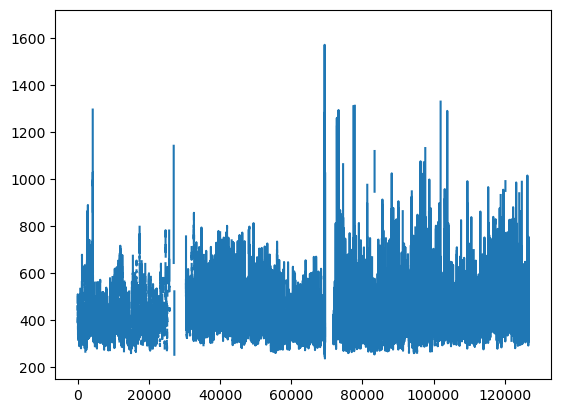

In [20]:
plt.plot(np.array(stereoA_hr['Vp_obs'][5000:]))

## Removing NaN values from all the data

In [21]:
# Just removing the NaN values

# Clean observational data
acel2_hr_clean = acel2_hr.dropna(subset=['Vp_obs'])
stereoA_hr_clean = stereoA_hr.dropna(subset=['Vp_obs'])

# Clean prediction data (Redundant)
field_line_03_R000_gongz_earth_clean = field_line_03_R000_gongz_earth.dropna(subset=['Vp'])
field_line_03_R000_gongz_mars_clean = field_line_03_R000_gongz_mars.dropna(subset=['Vp'])
field_line_03_R000_gongz_stereoa_clean = field_line_03_R000_gongz_stereoa.dropna(subset=['Vp'])

## Interpolating through the NaN data

In [22]:
# Interpolating through observational data
acel2_hr_interp = acel2_hr
acel2_hr_interp['Vp_obs'] = acel2_hr['Vp_obs'].interpolate()

stereoA_hr_interp= stereoA_hr
stereoA_hr_interp['Vp_obs'] = stereoA_hr['Vp_obs'].interpolate()

## Aligning Clean Data

In [23]:
def align_pred_to_obs(obs_df, pred_df, obs_col='Vp_obs', pred_col='Vp'):
    """Interpolate predicted values onto observational timestamps.

    Uses clean data (no NaN's). Only keeps
    observation times that fall inside the prediction time range so
    values are not extrapolated.
    """
    obs = obs_df.dropna(subset=[obs_col]).sort_values('juldate').copy()
    pred = (
        pred_df.dropna(subset=[pred_col])
        .sort_values('juldate')
        .drop_duplicates(subset='juldate', keep='first')
        .copy()
    )

    obs_t = obs['juldate'].astype('int64').to_numpy()
    pred_t = pred['juldate'].astype('int64').to_numpy()
    pred_y = pred[pred_col].to_numpy(dtype=float)

    # Keep only overlapping times (no extrapolation)
    in_range = (obs_t >= pred_t.min()) & (obs_t <= pred_t.max())
    obs_aligned = obs.loc[in_range].copy()
    obs_t = obs_t[in_range]

    obs_aligned['Vp_pred'] = np.interp(obs_t, pred_t, pred_y)
    obs_aligned['Vp_residual'] = obs_aligned[obs_col] - obs_aligned['Vp_pred']

    return obs_aligned.reset_index(drop=True)

### ACE

In [24]:
# Align Earth/ACE model predictions to ACE observations
ace_aligned = align_pred_to_obs(
    acel2_hr_clean,
    field_line_03_R000_gongz_earth_clean,
)

ace_aligned[['juldate', 'Vp_obs', 'Vp_pred', 'Vp_residual']].head()

,juldate,Vp_obs,Vp_pred,Vp_residual
0,2010-01-01 00:00:00.000000,276.62,305.991892,-29.371892
1,2010-01-01 00:57:36.000003,271.82,304.999556,-33.179556
2,2010-01-01 01:55:12.000006,273.09,304.007221,-30.917221
3,2010-01-01 02:52:48.000010,278.73,303.014885,-24.284885
4,2010-01-01 04:04:47.999994,271.79,301.774466,-29.984466


Text(0.5, 1.0, 'ACE aligned clean')

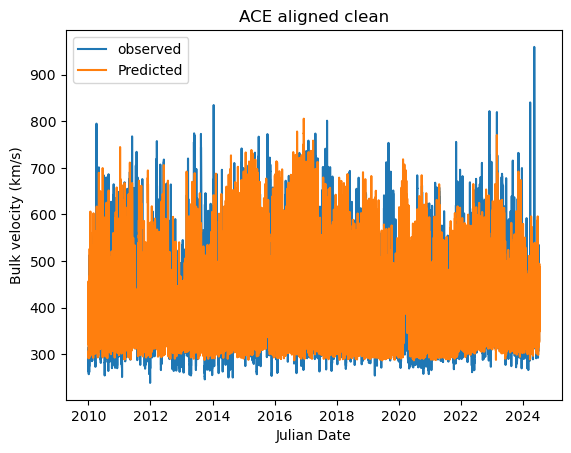

In [25]:
plt.plot(np.array(ace_aligned.juldate), np.array(ace_aligned.Vp_obs), label = 'observed')
plt.plot(np.array(ace_aligned.juldate), np.array(ace_aligned.Vp_pred), label = 'Predicted')
plt.legend()
plt.xlabel('Julian Date')
plt.ylabel('Bulk velocity (km/s)')
plt.title('ACE aligned clean')

### STEREO

In [26]:
# Align STEREO-A model predictions to STEREO-A observations
# Also drop a couple of clearly non-physical fill/outlier speeds in the obs
stereoA_hr_clean_phys = stereoA_hr_clean[
    (stereoA_hr_clean['Vp_obs'] > 200) & (stereoA_hr_clean['Vp_obs'] < 2000)
].copy()

stereoA_aligned = align_pred_to_obs(
    stereoA_hr_clean_phys,
    field_line_03_R000_gongz_stereoa_clean,
)

stereoA_aligned[['juldate', 'Vp_obs', 'Vp_pred', 'Vp_residual']].head()

,juldate,Vp_obs,Vp_pred,Vp_residual
0,2011-07-06 14:52:48.000010,412.12,368.308620,43.811380
1,2011-07-06 16:04:47.999994,406.24,371.805085,34.434915
2,2011-07-06 17:02:23.999997,406.48,374.602256,31.877744
3,2011-07-06 18:00:00.000000,401.15,377.399428,23.750572
4,2011-07-06 18:57:36.000003,381.91,380.196599,1.713401


Text(0.5, 1.0, 'STEREO aligned clean')

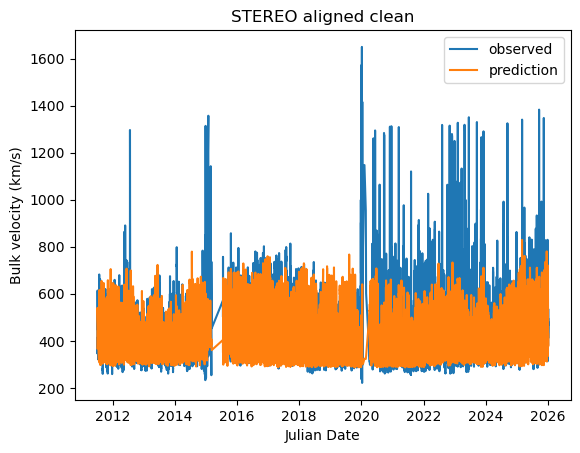

In [27]:
plt.plot(np.array(stereoA_aligned.juldate), np.array(stereoA_aligned.Vp_obs), label = 'observed')
plt.plot(np.array(stereoA_aligned.juldate), np.array(stereoA_aligned.Vp_pred), label = 'prediction')
plt.legend()
plt.xlabel('Julian Date')
plt.ylabel('Bulk velocity (km/s)')
plt.title('STEREO aligned clean')

## Aligning Interpolated Data

### ACE

In [28]:
ace_aligned_interp = align_pred_to_obs(
    acel2_hr_interp,
    field_line_03_R000_gongz_earth_clean,
)

ace_aligned_interp[['juldate', 'Vp_obs', 'Vp_pred', 'Vp_residual']].head()

,juldate,Vp_obs,Vp_pred,Vp_residual
0,2010-01-01 00:00:00.000000,276.62,305.991892,-29.371892
1,2010-01-01 00:57:36.000003,271.82,304.999556,-33.179556
2,2010-01-01 01:55:12.000006,273.09,304.007221,-30.917221
3,2010-01-01 02:52:48.000010,278.73,303.014885,-24.284885
4,2010-01-01 04:04:47.999994,271.79,301.774466,-29.984466


Text(0.5, 1.0, 'ACE aligned interpolated')

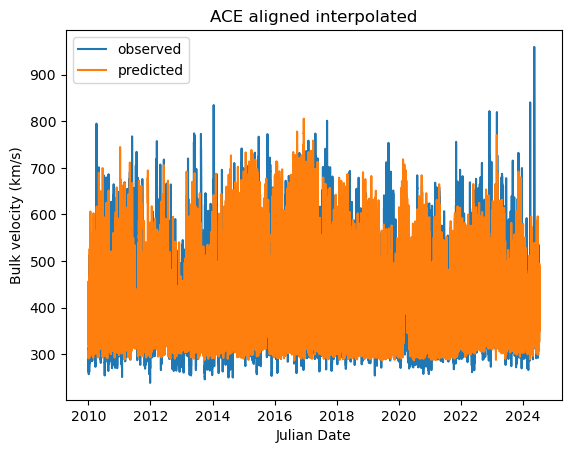

In [29]:
plt.plot(np.array(ace_aligned_interp.juldate), np.array(ace_aligned_interp.Vp_obs), label = 'observed')
plt.plot(np.array(ace_aligned_interp.juldate), np.array(ace_aligned_interp.Vp_pred), label = 'predicted')
plt.legend()
plt.xlabel('Julian Date')
plt.ylabel('Bulk velocity (km/s)')
plt.title('ACE aligned interpolated')

### STEREO

In [30]:
stereoA_hr_interp_phys = stereoA_hr_interp[
    (stereoA_hr_interp['Vp_obs'] > 200) & (stereoA_hr_interp['Vp_obs'] < 2000)
].copy()

stereoA_aligned_interp = align_pred_to_obs(
    stereoA_hr_interp_phys,
    field_line_03_R000_gongz_stereoa_clean,
)

stereoA_aligned_interp[['juldate', 'Vp_obs', 'Vp_pred', 'Vp_residual']].head()

,juldate,Vp_obs,Vp_pred,Vp_residual
0,2011-07-06 14:52:48.000010,412.12,368.308620,43.811380
1,2011-07-06 16:04:47.999994,406.24,371.805085,34.434915
2,2011-07-06 17:02:23.999997,406.48,374.602256,31.877744
3,2011-07-06 18:00:00.000000,401.15,377.399428,23.750572
4,2011-07-06 18:57:36.000003,381.91,380.196599,1.713401


Text(0.5, 1.0, 'STERO aligned interpolated')

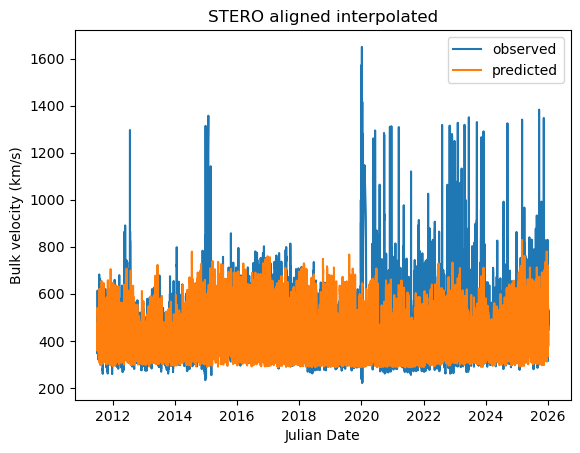

In [31]:
plt.plot(np.array(stereoA_aligned_interp.juldate), np.array(stereoA_aligned_interp.Vp_obs), label = 'observed')
plt.plot(np.array(stereoA_aligned_interp.juldate), np.array(stereoA_aligned_interp.Vp_pred), label = 'predicted')
plt.legend()
plt.xlabel('Julian Date')
plt.ylabel('Bulk velocity (km/s)')
plt.title('STERO aligned interpolated')

## Removing Transient Event Data

### ACE clean

All of this data removal was done on the "Clean" data. That is, the data with all NaN's removed. This is the case for both ACE and STEREO

In [35]:
# Remove CME events from ace_aligned using icmetable2.xlsx
icme = pd.read_excel(r'./icmetable2.xlsx')

in_cme = pd.Series(False, index=ace_aligned.index)

for i in range(len(icme)):
    start = pd.to_datetime(str(icme.iloc[i, 0]).split('(')[0].strip())
    end = pd.to_datetime(str(icme.iloc[i, 2]).split('(')[0].strip())

    in_cme = in_cme | ((ace_aligned['juldate'] >= start) & (ace_aligned['juldate'] <= end))

print(len(ace_aligned))
ace_aligned_no_cme = ace_aligned[~in_cme].reset_index(drop=True)
print(len(ace_aligned_no_cme))
print(len(ace_aligned)-len(ace_aligned_no_cme))


125806
117305
8501


Text(0, 0.5, 'Bulk velocity (km/s)')

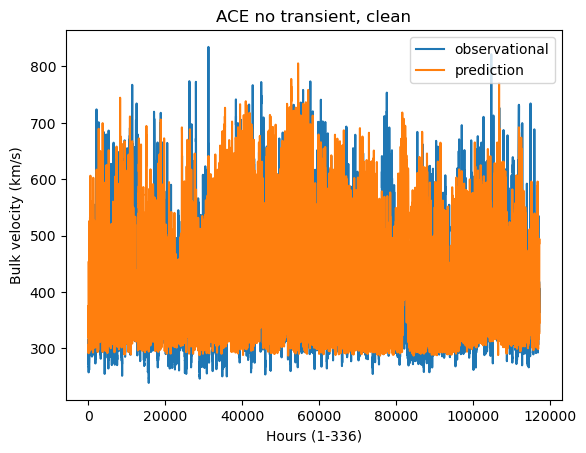

In [36]:
plt.plot(np.array(ace_aligned_no_cme['Vp_obs']), label = 'observational')
plt.plot(np.array(ace_aligned_no_cme['Vp_pred']), label = 'prediction')
plt.legend()
plt.title('ACE no transient, clean')
plt.xlabel('Hours (1-336)')
plt.ylabel('Bulk velocity (km/s)')

### STEREO clean

In [37]:
# Remove CME events from stereoA_aligned using STEREO_Level3_ICME.xlsx
icme = pd.read_excel(r'./STEREO_Level3_ICME.xlsx', header=None)

def parse_stereo_icme_time(value):
    text = str(value).strip().split('(')[0].strip()
    try:
        return pd.to_datetime(text, format='%Y %m/%d %H:%M')
    except (ValueError, TypeError):
        return pd.to_datetime(text, errors='coerce')

in_cme = pd.Series(False, index=stereoA_aligned.index)

for i in range(len(icme)):
    spacecraft = icme.iloc[i, 1]
    if pd.isna(spacecraft) or 'A' not in str(spacecraft).strip():
        continue

    start = parse_stereo_icme_time(icme.iloc[i, 2])
    end = parse_stereo_icme_time(icme.iloc[i, 4])
    if pd.isna(start) or pd.isna(end):
        continue

    in_cme = in_cme | ((stereoA_aligned['juldate'] >= start) & (stereoA_aligned['juldate'] <= end))

print(len(stereoA_aligned))
stereoA_aligned_no_cme = stereoA_aligned[~in_cme].reset_index(drop=True)
print(len(stereoA_aligned_no_cme))
print(len(stereoA_aligned) - len(stereoA_aligned_no_cme))

101091
93439
7652


Text(0, 0.5, 'Bulk velocity (km/s)')

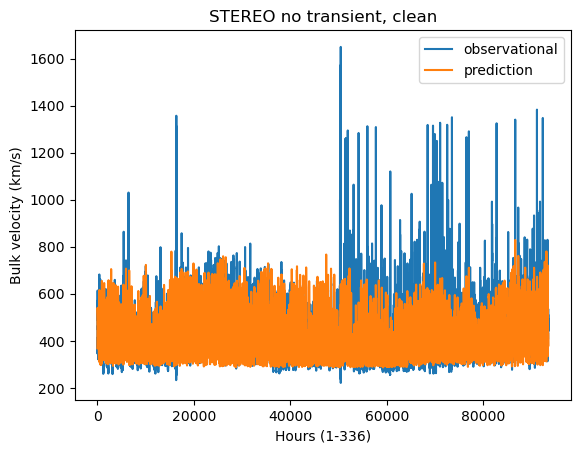

In [38]:
plt.plot(np.array(stereoA_aligned_no_cme['Vp_obs']), label = 'observational')
plt.plot(np.array(stereoA_aligned_no_cme['Vp_pred']), label = 'prediction')
plt.legend()
plt.title('STEREO no transient, clean')
plt.xlabel('Hours (1-336)')
plt.ylabel('Bulk velocity (km/s)')

### ACE interpolated

All of this data removal was done on the "Clean" data. That is, the data with all NaN's removed. This is the case for both ACE and STEREO

In [39]:
# Remove CME events from ace_aligned using icmetable2.xlsx
icme = pd.read_excel(r'./icmetable2.xlsx')

in_cme = pd.Series(False, index=ace_aligned_interp.index)

for i in range(len(icme)):
    start = pd.to_datetime(str(icme.iloc[i, 0]).split('(')[0].strip())
    end = pd.to_datetime(str(icme.iloc[i, 2]).split('(')[0].strip())

    in_cme = in_cme | ((ace_aligned_interp['juldate'] >= start) & (ace_aligned_interp['juldate'] <= end))

print(len(ace_aligned_interp))
ace_aligned_no_cme_interp = ace_aligned_interp[~in_cme].reset_index(drop=True)
print(len(ace_aligned_no_cme_interp))
print(len(ace_aligned_interp)-len(ace_aligned_no_cme_interp))


127320
118672
8648


Text(0, 0.5, 'Bulk velocity (km/s)')

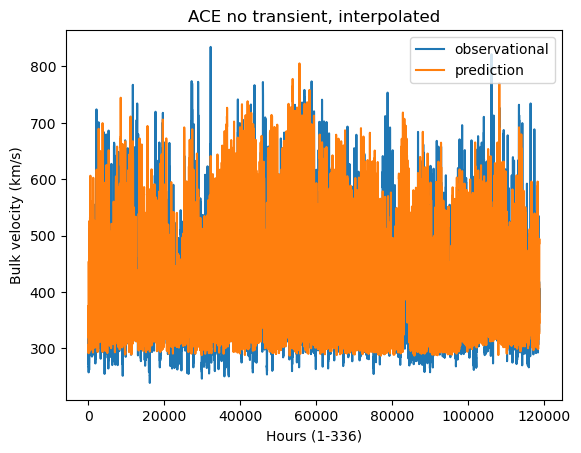

In [40]:
plt.plot(np.array(ace_aligned_no_cme_interp['Vp_obs']), label = 'observational')
plt.plot(np.array(ace_aligned_no_cme_interp['Vp_pred']), label = 'prediction')
plt.legend()
plt.title('ACE no transient, interpolated')
plt.xlabel('Hours (1-336)')
plt.ylabel('Bulk velocity (km/s)')

### STEREO interpolated

In [42]:
# Remove CME events from stereoA_aligned using STEREO_Level3_ICME.xlsx
icme = pd.read_excel(r'./STEREO_Level3_ICME.xlsx', header=None)

def parse_stereo_icme_time(value):
    text = str(value).strip().split('(')[0].strip()
    try:
        return pd.to_datetime(text, format='%Y %m/%d %H:%M')
    except (ValueError, TypeError):
        return pd.to_datetime(text, errors='coerce')

in_cme = pd.Series(False, index=stereoA_aligned_interp.index)

for i in range(len(icme)):
    spacecraft = icme.iloc[i, 1]
    if pd.isna(spacecraft) or 'A' not in str(spacecraft).strip():
        continue

    start = parse_stereo_icme_time(icme.iloc[i, 2])
    end = parse_stereo_icme_time(icme.iloc[i, 4])
    if pd.isna(start) or pd.isna(end):
        continue

    in_cme = in_cme | ((stereoA_aligned_interp['juldate'] >= start) & (stereoA_aligned_interp['juldate'] <= end))

print(len(stereoA_aligned_interp))
stereoA_aligned_no_cme_interp = stereoA_aligned_interp[~in_cme].reset_index(drop=True)
print(len(stereoA_aligned_no_cme_interp))
print(len(stereoA_aligned_interp) - len(stereoA_aligned_no_cme_interp))

127069
116906
10163


Text(0, 0.5, 'Bulk velocity (km/s)')

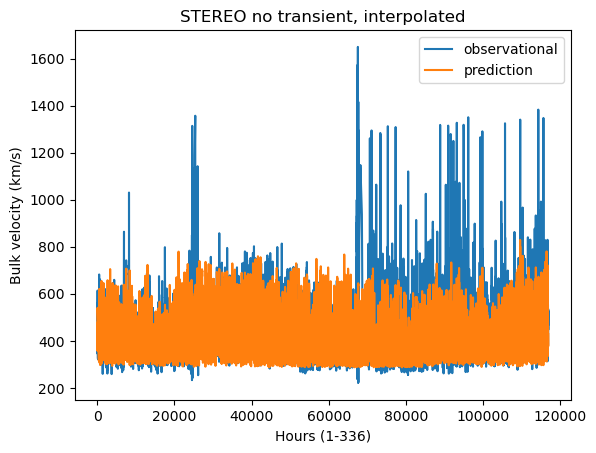

In [43]:
plt.plot(np.array(stereoA_aligned_no_cme_interp['Vp_obs']), label = 'observational')
plt.plot(np.array(stereoA_aligned_no_cme_interp['Vp_pred']), label = 'prediction')
plt.legend()
plt.title('STEREO no transient, interpolated')
plt.xlabel('Hours (1-336)')
plt.ylabel('Bulk velocity (km/s)')

# Analysis

Find the RMS for the velocities. ACE will have 1 measurement/hr while WSA predicitons are at irregular spacings. Interpolate the data and sync them up

## RMS for all the solar wind data

### Clean

In [44]:
acel2_hr_rms = np.sqrt(np.mean(acel2_hr_clean.Vp_obs**2))
print(acel2_hr_rms)
print(np.std(acel2_hr_clean.Vp_obs))

425.3517936381175
89.52529802378635


In [45]:
# Seems too high to be regular solar wind data, probably includes the transient CME's and whatnot. I don't have
stereoA_hr_rms = np.sqrt(np.mean(stereoA_hr_clean.Vp_obs**2))
print(stereoA_hr_rms)
print(np.std(stereoA_hr_clean.Vp_obs))

137897.23964595224
137894.42766120748


In [46]:
field_line_03_R000_gongz_earth_rms = np.sqrt(np.mean(field_line_03_R000_gongz_earth_clean.Vp**2))
print(field_line_03_R000_gongz_earth_rms)
print(np.std(field_line_03_R000_gongz_earth_clean.Vp))

408.92418641403265
99.53553709016356


In [47]:
field_line_03_R000_gongz_mars_rms = np.sqrt(np.mean(field_line_03_R000_gongz_mars_clean.Vp**2))
print(field_line_03_R000_gongz_mars_rms)
print(np.std(field_line_03_R000_gongz_mars_clean.Vp))

372.94426307071853
80.6699893579584


In [48]:
field_line_03_R000_gongz_stereoa_rms = np.sqrt(np.mean(field_line_03_R000_gongz_stereoa_clean.Vp**2))
print(field_line_03_R000_gongz_stereoa_rms)
print(np.std(field_line_03_R000_gongz_stereoa_clean.Vp))

413.5852383048754
102.33464041588283


## Root Mean Error Calculations for ACE and STEREO

In [49]:
ace_rmse = np.sqrt(np.mean((ace_aligned['Vp_obs']-ace_aligned['Vp_pred'])**2))
print(ace_rmse)

104.66531143275145


In [50]:
stereoA_rmse = np.sqrt(np.mean((stereoA_aligned['Vp_obs']-stereoA_aligned['Vp_pred'])**2))
print(stereoA_rmse)

109.72137903138254


## RMSE Analysis

In [51]:
# ACE and STEREO with transient data, clean
ace_clean_rms_error, stero_clean_rms_error = rmse_year_data(ace_aligned, stereoA_aligned)

# ACE and STEREO without transient data, clean
ace_nt_error, stero_nt_error = rmse_year_data(ace_aligned_no_cme, stereoA_aligned_no_cme)

# ACE and STEREO with transient data, interpolated
ace_rms_interp_error, stero_interp_rms_error = rmse_year_data(ace_aligned_interp, stereoA_aligned_interp)

# ACE and STEREO without transient data, interpolated
ace_rms_interp_error_nt, stero_interp_rms_error_nt = rmse_year_data(ace_aligned_no_cme_interp, stereoA_aligned_no_cme_interp)

### RMSE including transient events, clean

Note that this is the clean data (NaN's removed) but not interpolated over the missing chunks of data post-removal

Text(0, 0.5, 'RMSE (km/s)')

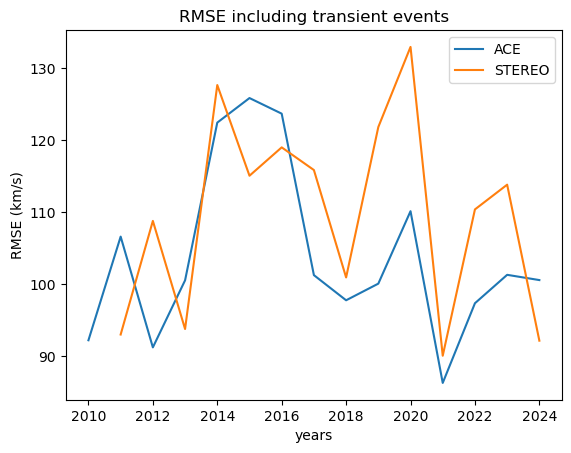

In [52]:
plt.plot(ace_clean_rms_error.keys(), ace_clean_rms_error.values(), label = 'ACE')
plt.plot(stero_clean_rms_error.keys(), stero_clean_rms_error.values(), label = 'STEREO')
plt.legend()
plt.title('RMSE including transient events')
plt.xlabel('years')
plt.ylabel('RMSE (km/s)')

### RMSE without transient events, clean

Note that this is the clean data (NaN's removed) but not interpolated over the missing chunks of data post-removal

In [53]:
ace_nt_error, stero_nt_error = rmse_year_data(ace_aligned_no_cme, stereoA_aligned_no_cme)

Text(0, 0.5, 'RMSE (km/s)')

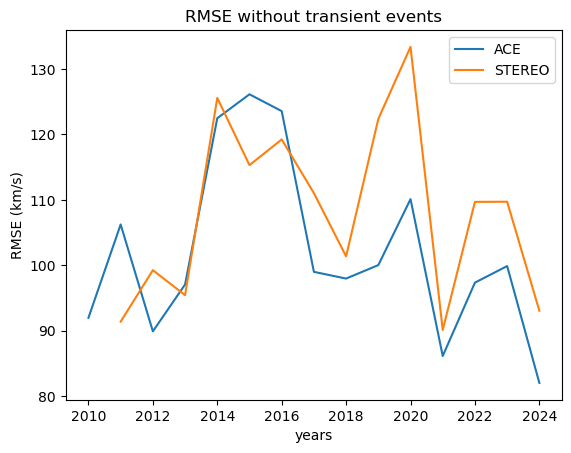

In [54]:
plt.plot(ace_nt_error.keys(), ace_nt_error.values(), label = 'ACE')
plt.plot(stero_nt_error.keys(), stero_nt_error.values(), label = 'STEREO')
plt.legend()
plt.title('RMSE without transient events')
plt.xlabel('years')
plt.ylabel('RMSE (km/s)')

### RMSE including transient events, interpolated

Text(0, 0.5, 'RMSE (km/s)')

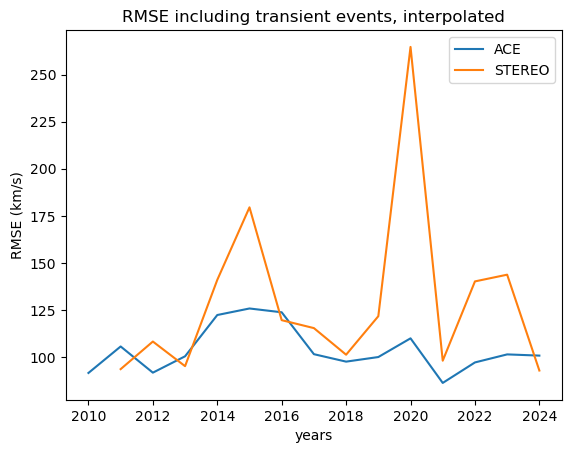

In [55]:
plt.plot(ace_rms_interp_error.keys(), ace_rms_interp_error.values(), label = 'ACE')
plt.plot(stero_interp_rms_error.keys(), stero_interp_rms_error.values(), label = 'STEREO')
plt.legend()
plt.title('RMSE including transient events, interpolated')
plt.xlabel('years')
plt.ylabel('RMSE (km/s)')

### RMSE without transient events, interpolated

Text(0, 0.5, 'RMSE (km/s)')

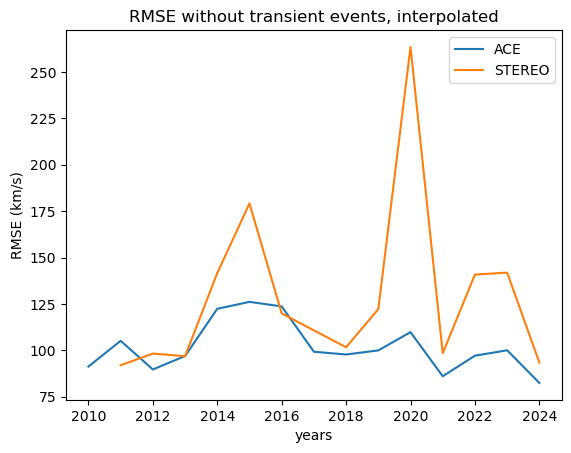

In [56]:
plt.plot(ace_rms_interp_error_nt.keys(), ace_rms_interp_error_nt.values(), label = 'ACE')
plt.plot(stero_interp_rms_error_nt.keys(), stero_interp_rms_error_nt.values(), label = 'STEREO')
plt.legend()
plt.title('RMSE without transient events, interpolated')
plt.xlabel('years')
plt.ylabel('RMSE (km/s)')

### Clean side-by-side

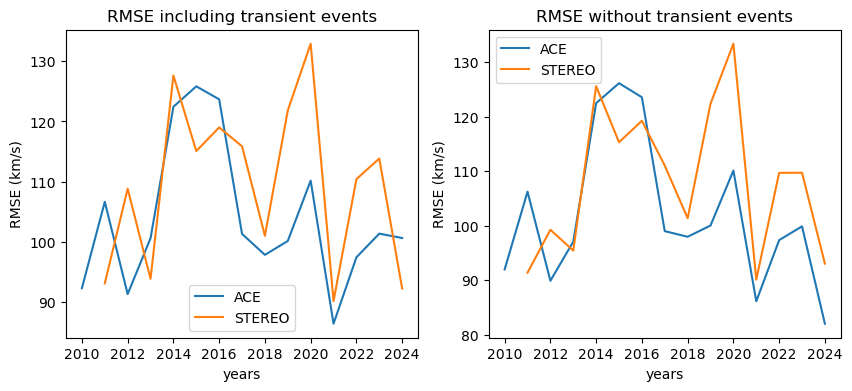

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(ace_clean_rms_error.keys(), ace_clean_rms_error.values(), label='ACE')
axes[0].plot(stero_clean_rms_error.keys(), stero_clean_rms_error.values(), label='STEREO')
axes[0].legend()
axes[0].set_title('RMSE including transient events')
axes[0].set_xlabel('years')
axes[0].set_ylabel('RMSE (km/s)')

axes[1].plot(ace_nt_error.keys(), ace_nt_error.values(), label='ACE')
axes[1].plot(stero_nt_error.keys(), stero_nt_error.values(), label='STEREO')
axes[1].legend()
axes[1].set_title('RMSE without transient events')
axes[1].set_xlabel('years')
axes[1].set_ylabel('RMSE (km/s)')

plt.show()


### Interpolated side-by-side

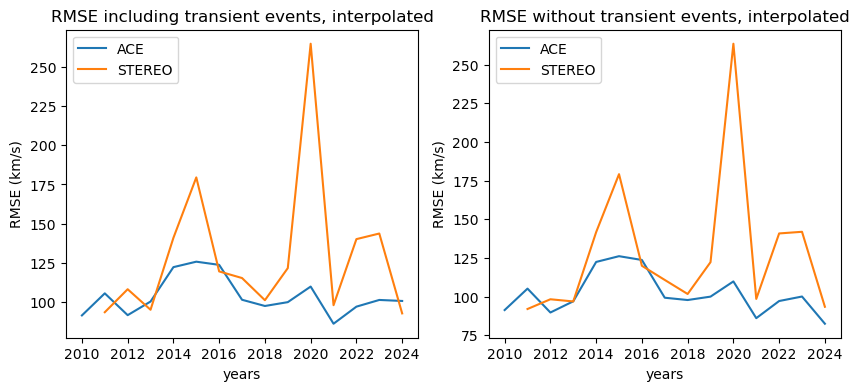

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(ace_rms_interp_error.keys(), ace_rms_interp_error.values(), label='ACE')
axes[0].plot(stero_interp_rms_error.keys(), stero_interp_rms_error.values(), label='STEREO')
axes[0].legend()
axes[0].set_title('RMSE including transient events, interpolated')
axes[0].set_xlabel('years')
axes[0].set_ylabel('RMSE (km/s)')

axes[1].plot(ace_rms_interp_error_nt.keys(), ace_rms_interp_error_nt.values(), label='ACE')
axes[1].plot(stero_interp_rms_error_nt.keys(), stero_interp_rms_error_nt.values(), label='STEREO')
axes[1].legend()
axes[1].set_title('RMSE without transient events, interpolated')
axes[1].set_xlabel('years')
axes[1].set_ylabel('RMSE (km/s)')

plt.show()


## Two weeks of random ACE and STEREO data

In [59]:
# 336 hours in 2 weeks, randomly sample 336 points from the aligned data
# This format has the jul dates save as well
# Random seed is 42 for reproducibility
np.random.seed(10)
start = np.random.randint(0, len(ace_aligned)-336+1)
two_weeks_ace = ace_aligned.iloc[start:start+336]
two_weeks_stereo = stereoA_aligned.iloc[start:start+336]

Text(0, 0.5, 'Bulk velocity (km/s)')

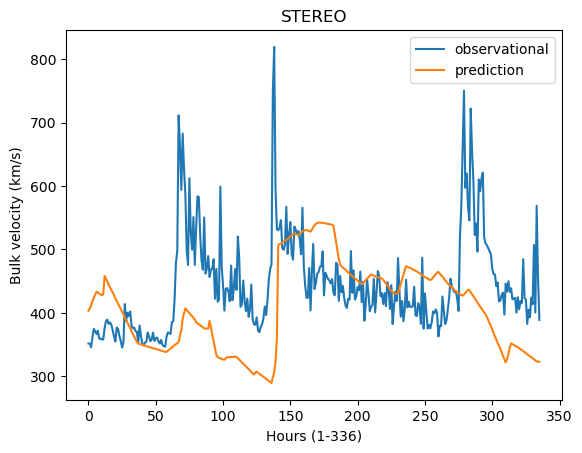

In [60]:
plt.plot(np.array(two_weeks_stereo['Vp_obs']), label = 'observational')
plt.plot(np.array(two_weeks_stereo['Vp_pred']), label = 'prediction')
plt.legend()
plt.title('STEREO')
plt.xlabel('Hours (1-336)')
plt.ylabel('Bulk velocity (km/s)')

Text(0, 0.5, 'Bulk velocity (km/s)')

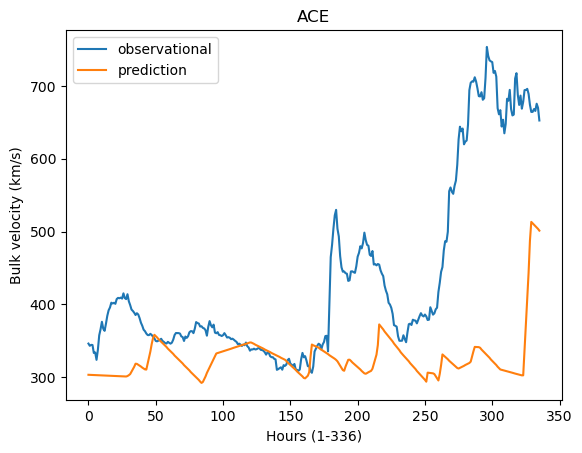

In [61]:
plt.plot(np.array(two_weeks_ace['Vp_obs']), label = 'observational')
plt.plot(np.array(two_weeks_ace['Vp_pred']), label = 'prediction')
plt.legend()
plt.title('ACE')
plt.xlabel('Hours (1-336)')
plt.ylabel('Bulk velocity (km/s)')

## Interactible clock diagram

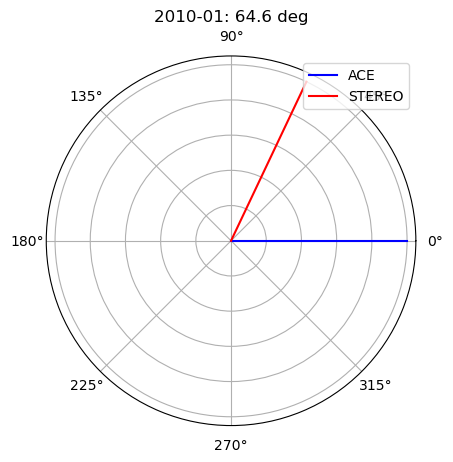

interactive(children=(IntSlider(value=2010, description='year', max=2024, min=2010), IntSlider(value=1, descri…

In [62]:
@interact(year=(2010, 2024), month=(1, 12))
def clock(year=2010, month=1):
    start_date = datetime(year, month, 1)
    if month == 12:
        end_date = datetime(year + 1, 1, 1)
    else:
        end_date = datetime(year, month + 1, 1)

    ace_m = acel2_locs[(acel2_locs.juldate >= start_date) & (acel2_locs.juldate < end_date)]
    sta_m = stereoA_locs[(stereoA_locs.juldate >= start_date) & (stereoA_locs.juldate < end_date)]
    m = ace_m.merge(sta_m, on='sat_time_jd', suffixes=('_ace', '_sta'))

    # daily separations, then circular mean (don't average longitudes first)
    delta = (m['sat_lon_sta'] - m['sat_lon_ace']) % 360
    sep = np.rad2deg(np.angle(np.mean(np.exp(1j * np.deg2rad(delta)))))

    fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
    ax.plot([0, 0], [0, 1], 'b-', label='ACE')
    ax.plot([0, np.deg2rad(sep)], [0, 1], 'r-', label='STEREO')
    ax.set_yticklabels([])
    ax.set_title(f'{year}-{month:02d}: {abs(sep):.1f} deg')
    ax.legend(loc='upper right')
    plt.show()


# Looking at changing ways to smooth STERO data

## Moving Average

### interpolated without transient events

In [63]:
# Extremely basic moving average on STEREO interpolated data without transient events
window = 24  # hours since data is hourly, arbitrarily chose 24 because its nice

stereoA_ma = stereoA_aligned_no_cme_interp.copy()
stereoA_ma['Vp_obs_ma'] = moving_average(stereoA_ma['Vp_obs'], window)
stereoA_ma['Vp_pred_ma'] = moving_average(stereoA_ma['Vp_pred'], window)

# print(f'Window size: {window} hours')
# stereoA_ma[['juldate', 'Vp_obs', 'Vp_obs_ma', 'Vp_pred', 'Vp_pred_ma']].head(30)

Text(0, 0.5, 'Bulk velocity (km/s)')

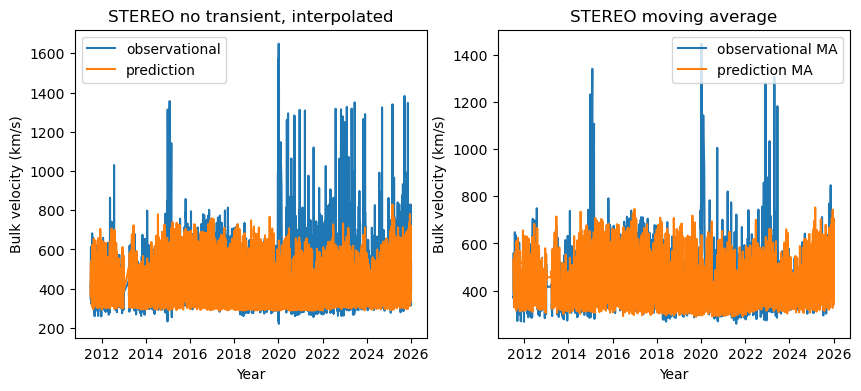

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(np.array(stereoA_ma['juldate']), np.array(stereoA_ma['Vp_obs']), label='observational')
axes[0].plot(np.array(stereoA_ma['juldate']), np.array(stereoA_ma['Vp_pred']), label='prediction')
axes[0].legend()
axes[0].set_title('STEREO no transient, interpolated')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Bulk velocity (km/s)')

axes[1].plot(np.array(stereoA_ma['juldate']), np.array(stereoA_ma['Vp_obs_ma']), label='observational MA')
axes[1].plot(np.array(stereoA_ma['juldate']), np.array(stereoA_ma['Vp_pred_ma']), label='prediction MA')
axes[1].legend()
axes[1].set_title('STEREO moving average')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Bulk velocity (km/s)')